# Supermart Sales Analysis

This notebook performs an exploratory data analysis on the Supermart sales dataset. It includes data preprocessing, visualization, and insights generation to help improve business strategy.


# Importing the libraries


## Data Visualization

Visualize the data to identify trends and patterns.


In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

import warnings 
warnings.filterwarnings('ignore')

# Load the dataset


## Load Dataset

We begin by importing the dataset using `pandas`.


In [2]:
supermart = pd.read_csv(
    r"E:\Unified Mentor Project\Supermart Grocery Sales\Supermart_Grocery_Sales_Updated.csv"
)

supermart.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


In [3]:
# Check the shape of the dataset
supermart.shape

(9994, 11)

# Data Preprocessing


## 1. Check the data types of the columns, missing values and handling them


## Descriptive Statistics

Summary of numerical features in the dataset.


In [4]:
supermart.select_dtypes(include=["float", "int"]).describe().round(2)

,Sales,Discount,Profit
count,9994.00,9994.00,9994.00
mean,1496.60,0.23,374.94
std,577.56,0.07,239.93
min,500.00,0.10,25.25
25%,1000.00,0.16,180.02
50%,1498.00,0.23,320.78
75%,1994.75,0.29,525.63
max,2500.00,0.35,1120.95


## Descriptive Statistics

Summary of numerical features in the dataset.


In [5]:
supermart.describe()

,Sales,Discount,Profit
count,9994.000000,9994.000000,9994.000000
mean,1496.596158,0.226817,374.937082
std,577.559036,0.074636,239.932881
min,500.000000,0.100000,25.250000
25%,1000.000000,0.160000,180.022500
50%,1498.000000,0.230000,320.780000
75%,1994.750000,0.290000,525.627500
max,2500.000000,0.350000,1120.950000


In [6]:
# Checking the data types
supermart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   object 
 1   Customer Name  9994 non-null   object 
 2   Category       9994 non-null   object 
 3   Sub Category   9994 non-null   object 
 4   City           9994 non-null   object 
 5   Order Date     9994 non-null   object 
 6   Region         9994 non-null   object 
 7   Sales          9994 non-null   int64  
 8   Discount       9994 non-null   float64
 9   Profit         9994 non-null   float64
 10  State          9994 non-null   object 
dtypes: float64(2), int64(1), object(8)
memory usage: 859.0+ KB


## Missing Values Check

Identify and count any missing values in the dataset.


In [7]:
# checking the missing values
supermart.isnull().sum()

Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

In [8]:
supermart.columns = supermart.columns.str.replace(" ", "_")

## Aggregated Analysis

Group data by categories (e.g., Segment, Category) to analyze sales and profit.


In [9]:
supermart.groupby(["Category", "Sub_Category"])["Sales"].sum().sort_values(
    ascending=False
).head(10).rolling(1).sum()

Category      Sub_Category 
Beverages     Health Drinks    1051439.0
              Soft Drinks      1033874.0
Snacks        Cookies           768213.0
Bakery        Breads & Buns     742586.0
Snacks        Noodles           735435.0
              Chocolates        733898.0
Oil & Masala  Masalas           697480.0
Bakery        Cakes             685612.0
              Biscuits          684083.0
Oil & Masala  Spices            672876.0
Name: Sales, dtype: float64

## Aggregated Analysis

Group data by categories (e.g., Segment, Category) to analyze sales and profit.


In [10]:
supermart.groupby(["Category", "City", "Region"]).agg({"Sales": "sum"}).sort_values(
    by=["Sales"], ascending=False
).reset_index()

,Category,City,Region,Sales
0,Bakery,Salem,East,45524
1,Oil & Masala,Pudukottai,East,44795
2,Fruits & Veggies,Bodi,West,44550
3,"Eggs, Meat & Fish",Karur,West,44254
4,Food Grains,Bodi,West,43681
...,...,...,...,...
668,Fruits & Veggies,Tenkasi,South,6079
669,Beverages,Chennai,South,5496
670,Fruits & Veggies,Cumbum,South,5339
671,"Eggs, Meat & Fish",Pudukottai,South,3275


In [11]:
## 2. Converting Date columns to DateTime format
from dateutil.parser import parse
import pandas as pd

supermart["Order_Date"] = supermart["Order_Date"].apply(
    lambda x: parse(x) if isinstance(x, str) else x
)


supermart["Order_Date"].dtype

supermart["Order_Date"].head()

0   2017-11-08
1   2017-11-08
2   2017-06-12
3   2016-10-11
4   2016-10-11
Name: Order_Date, dtype: datetime64[ns]

In [12]:
# Extract day, month and year from the Order Date column

supermart["Order_Year"] = supermart["Order_Date"].dt.year
supermart["Order_Month"] = supermart["Order_Date"].dt.month
supermart["Order_Day"] = supermart["Order_Date"].dt.day

supermart["Order_Year"].head()

0    2017
1    2017
2    2017
3    2016
4    2016
Name: Order_Year, dtype: int32

In [13]:
supermart.head()

,Order_ID,Customer_Name,Category,Sub_Category,City,Order_Date,Region,Sales,Discount,Profit,State,Order_Year,Order_Month,Order_Day
0,OD1,Harish,Oil & Masala,Masalas,Vellore,2017-11-08,North,1254,0.12,401.28,Tamil Nadu,2017,11,8
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,2017-11-08,South,749,0.18,149.80,Tamil Nadu,2017,11,8
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,2017-06-12,West,2360,0.21,165.20,Tamil Nadu,2017,6,12
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,2016-10-11,South,896,0.25,89.60,Tamil Nadu,2016,10,11
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,2016-10-11,South,2355,0.26,918.45,Tamil Nadu,2016,10,11


## Descriptive Statistics

Summary of numerical features in the dataset.


In [ ]:
# Check the data types again
supermart.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
Order_Date,9994,2017-04-30 05:17:08.056834048,2015-01-03 00:00:00,2016-05-23 00:00:00,2017-06-26 00:00:00,2018-05-14 00:00:00,2018-12-30 00:00:00,NaN
Sales,9994.0,1496.596158,500.0,1000.0,1498.0,1994.75,2500.0,577.559036
Discount,9994.0,0.226817,0.1,0.16,0.23,0.29,0.35,0.074636
Profit,9994.0,374.937082,25.25,180.0225,320.78,525.6275,1120.95,239.932881
Order_Year,9994.0,2016.722233,2015.0,2016.0,2017.0,2018.0,2018.0,1.123555
Order_Month,9994.0,7.809686,1.0,5.0,9.0,11.0,12.0,3.284654
Order_Day,9994.0,15.468381,1.0,8.0,15.0,23.0,31.0,8.748178


# Exploratory Data Analysis


## Data Visualization

Visualize the data to identify trends and patterns.


<Figure size 1000x600 with 0 Axes>

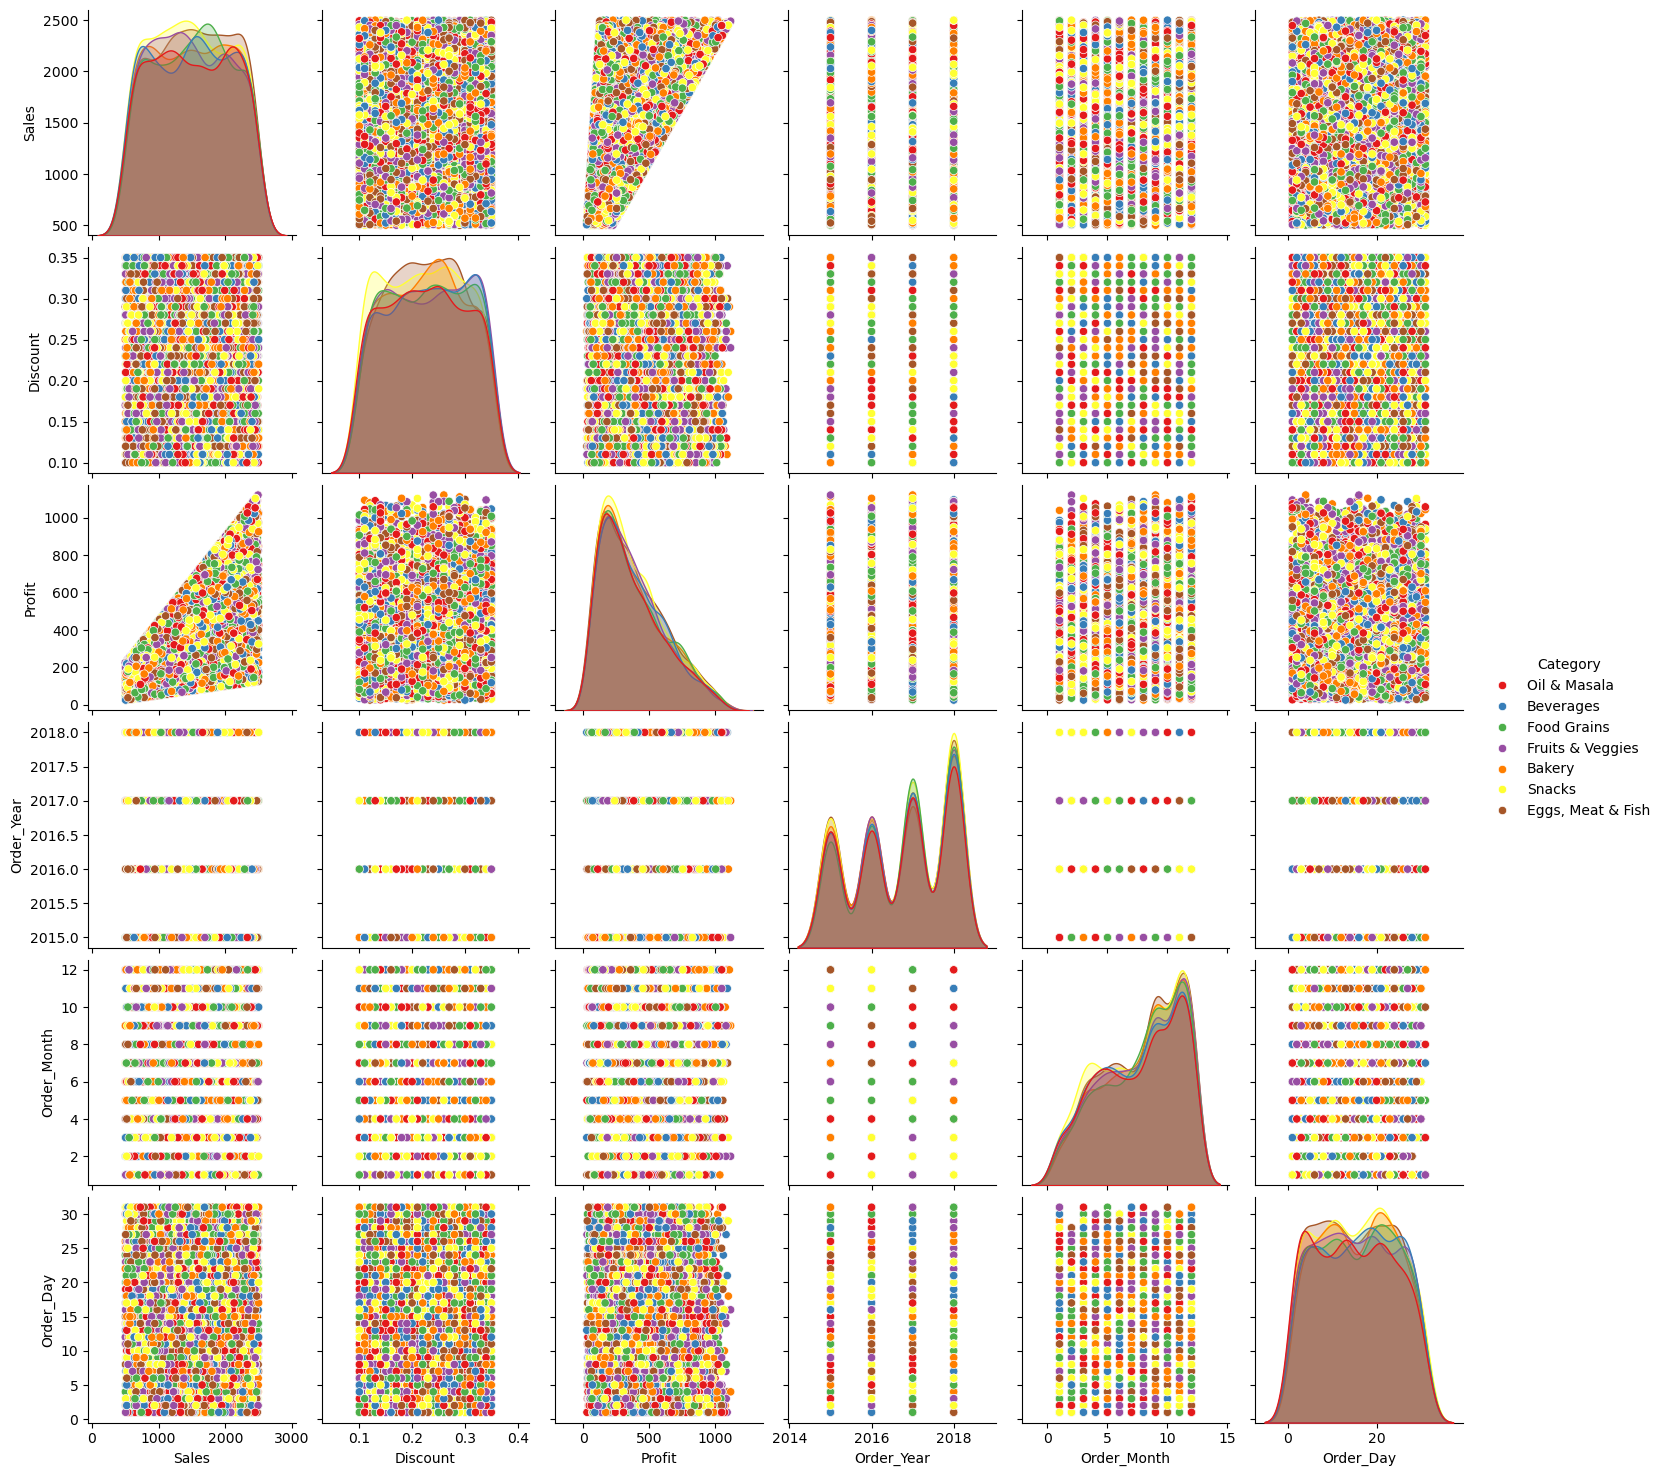

In [15]:
plt.figure(figsize=(10, 6))

sns.pairplot(supermart, hue="Category", palette="Set1")
plt.show()

## Aggregated Analysis

Group data by categories (e.g., Segment, Category) to analyze sales and profit.


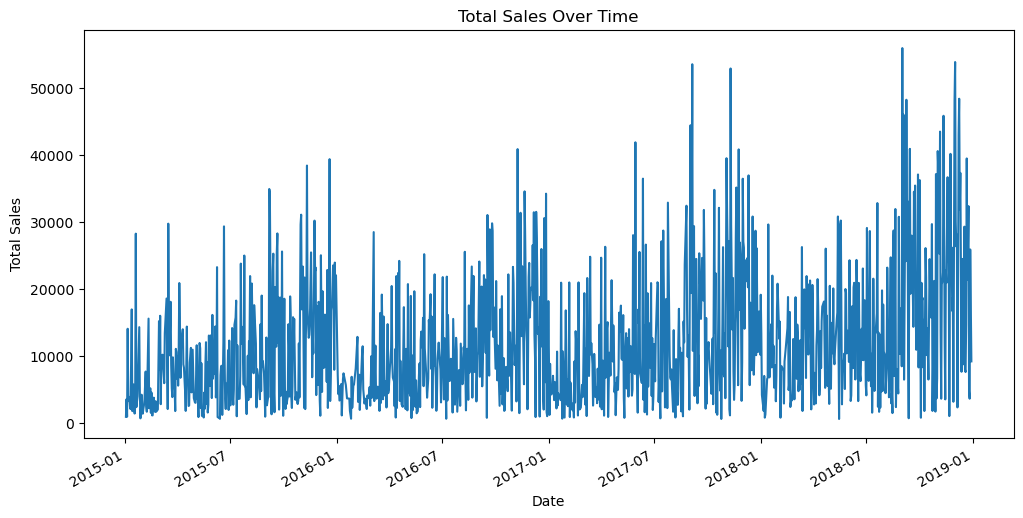

In [16]:
# 2. Sales Trends Over Time
plt.figure(figsize=(12, 6))
supermart.groupby("Order_Date")["Sales"].sum().plot()
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()

## Data Visualization

Visualize the data to identify trends and patterns.


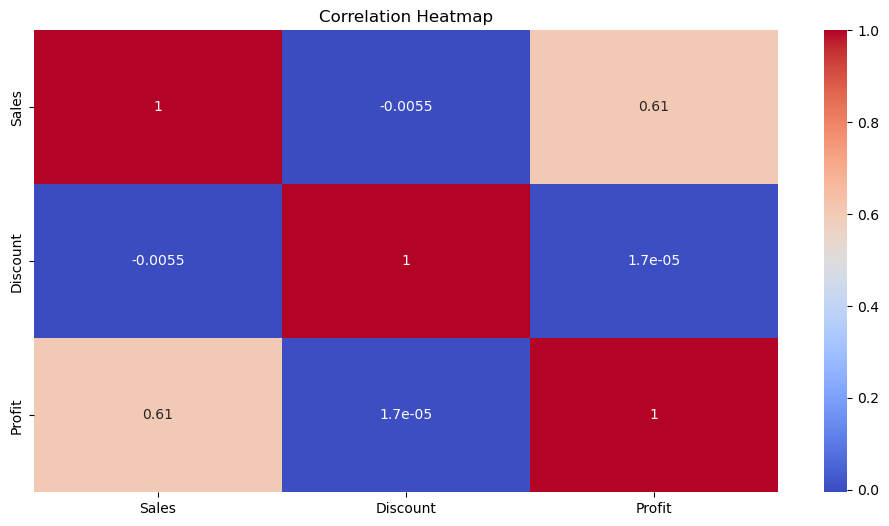

In [17]:
# 3. Correlation Heatmap
plt.figure(figsize=(12, 6))
corr_matrix = supermart.select_dtypes(include=["float64", "int64"]).corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## Aggregated Analysis

Group data by categories (e.g., Segment, Category) to analyze sales and profit.


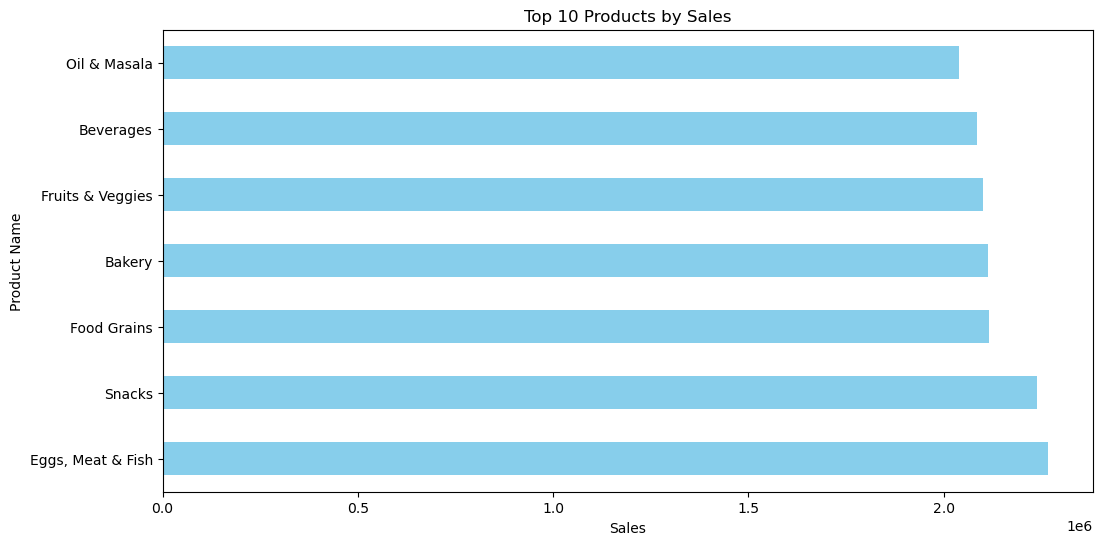

In [18]:
# Top 10 Products by Sales
top_10_products = supermart.groupby("Category")["Sales"].sum().nlargest(10)
plt.figure(figsize=(12, 6))
top_10_products.plot(kind="barh", color="skyblue")
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product Name")
plt.show()

### Eggs, Meat, Fish, and Snacks are the top 4 products by sales


## Aggregated Analysis

Group data by categories (e.g., Segment, Category) to analyze sales and profit.


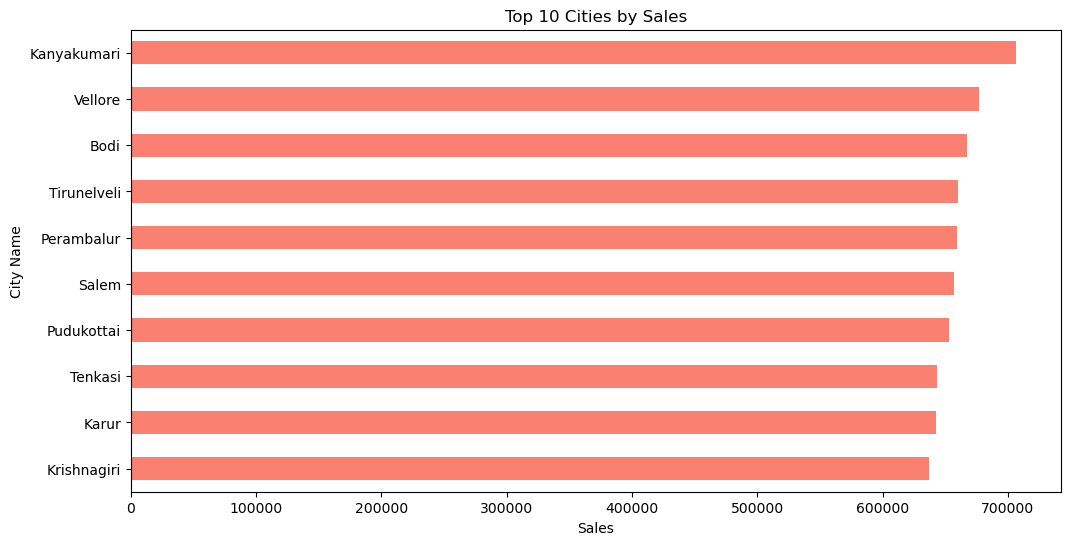

In [19]:
# Top 10 Cities by Sales
top_10_cities = (
    supermart.groupby("City")["Sales"].sum().nlargest(10).sort_values(ascending=True)
)

plt.figure(figsize=(12, 6))
top_10_cities.plot(kind="barh", color="salmon")
plt.title("Top 10 Cities by Sales")
plt.xlabel("Sales")
plt.ylabel("City Name")
plt.show()

### Kanyakumari Plays a Major Role in Sales


## Aggregated Analysis

Group data by categories (e.g., Segment, Category) to analyze sales and profit.


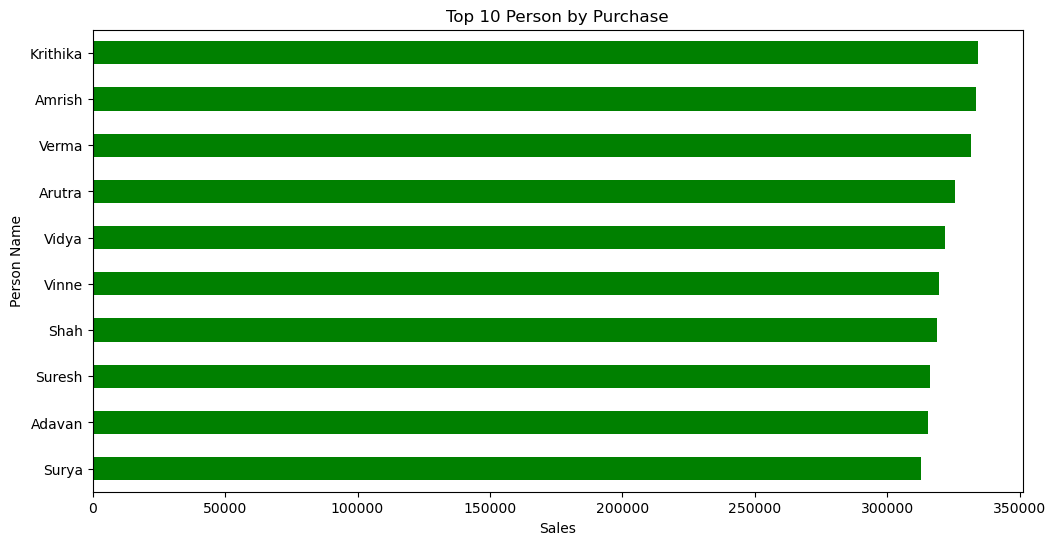

In [20]:
# Top 10 person with Highest purchase
top_10_person = (
    supermart.groupby("Customer_Name")["Sales"]
    .sum()
    .nlargest(10)
    .sort_values(ascending=True)
)

plt.figure(figsize=(12, 6))

top_10_person.plot(kind="barh", color="green")
plt.title("Top 10 Person by Purchase")
plt.xlabel("Sales")
plt.ylabel("Person Name")
plt.show()

### Krithika, Amrish, Verma purchased the most items from the Supermart store.


## Aggregated Analysis

Group data by categories (e.g., Segment, Category) to analyze sales and profit.


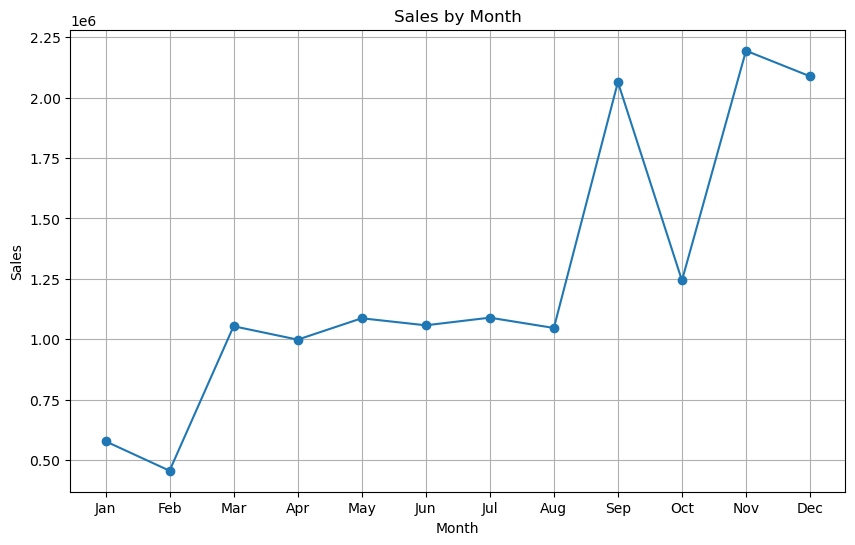

In [ ]:
# Sum up sales by month
monthly_sales = supermart.groupby("Order_Month")["Sales"].sum().reset_index()
# Sort the data by month
monthly_sales_sorted = monthly_sales.sort_values(by="Order_Month")
# Create the line chart
plt.figure(figsize=(10, 6))
plt.plot(monthly_sales_sorted["Order_Month"], monthly_sales_sorted["Sales"], marker="o")
plt.title("Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(
    monthly_sales_sorted["Order_Month"],
    [
        "Jan",
        "Feb",
        "Mar",
        "Apr",
        "May",
        "Jun",
        "Jul",
        "Aug",
        "Sep",
        "Oct",
        "Nov",
        "Dec",
    ],
)
plt.grid(True)
plt.show()

### During the Month of January, and February, the sales are very low.

### The sales are very high during the month of September, and December.


## Aggregated Analysis

Group data by categories (e.g., Segment, Category) to analyze sales and profit.


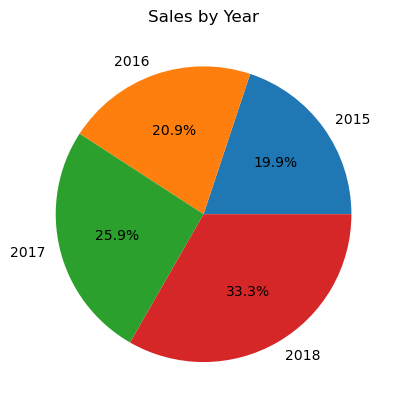

In [24]:
# we want to find the Yearly Sales
# we group by Year and get the total number of sales for each

Yearly_Sales = supermart.groupby("Order_Year")["Sales"].sum()
# we create a pie chart with the sales by year
plt.pie(Yearly_Sales, labels=Yearly_Sales.index, autopct="%1.1f%%")
plt.title("Sales by Year")
plt.show()

## The year 2017 and 2018 had more than 50 percent of the total sales which, implies the sales increase as the year increases.
